# Zomato Bengaluru - Feature Engineering
Shows **before / after** for each of the 5 engineered features with value counts and distribution plots.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

PALETTE = 'Set2'
FIG_DIR = pathlib.Path('../outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid', palette=PALETTE, font_scale=1.15)
matplotlib.rcParams['figure.dpi'] = 120

def save_fig(name):
    path = FIG_DIR / name
    plt.savefig(path, bbox_inches='tight')
    print(f'Saved -> {path}')

# Load RAW (pre-engineering) and CLEAN (post-engineering) datasets
raw   = pd.read_csv('../data/raw/zomato_raw.csv', encoding='latin-1')
clean = pd.read_csv('../data/processed/zomato_clean.csv')
clean['rating_bucket'] = pd.Categorical(
    clean['rating_bucket'],
    categories=['Poor','Average','Good','Excellent'], ordered=True
)
print(f'Raw  : {raw.shape}  |  Clean: {clean.shape}')


Raw  : (5610, 17)  |  Clean: (5500, 17)


---
## Feature 1 — `cuisine_count`
**What it is:** Number of distinct cuisines a restaurant serves.

**Before:** Raw `cuisines` column is a comma-separated string.

**After:** Integer count per restaurant.


=== BEFORE: raw cuisines sample ===
0    Burger, Continental, Beverages
1             Desserts, Continental
2                              Thai
3                         Beverages
4                         Fast Food
5                       Continental
6           Sandwich, Mediterranean
7                    Mexican, Momos

=== AFTER: cuisine_count value counts ===
cuisine_count
1    1819
2    1855
3    1826
Name: count, dtype: int64


Saved -> ..\outputs\figures\fe_01_cuisine_count.png


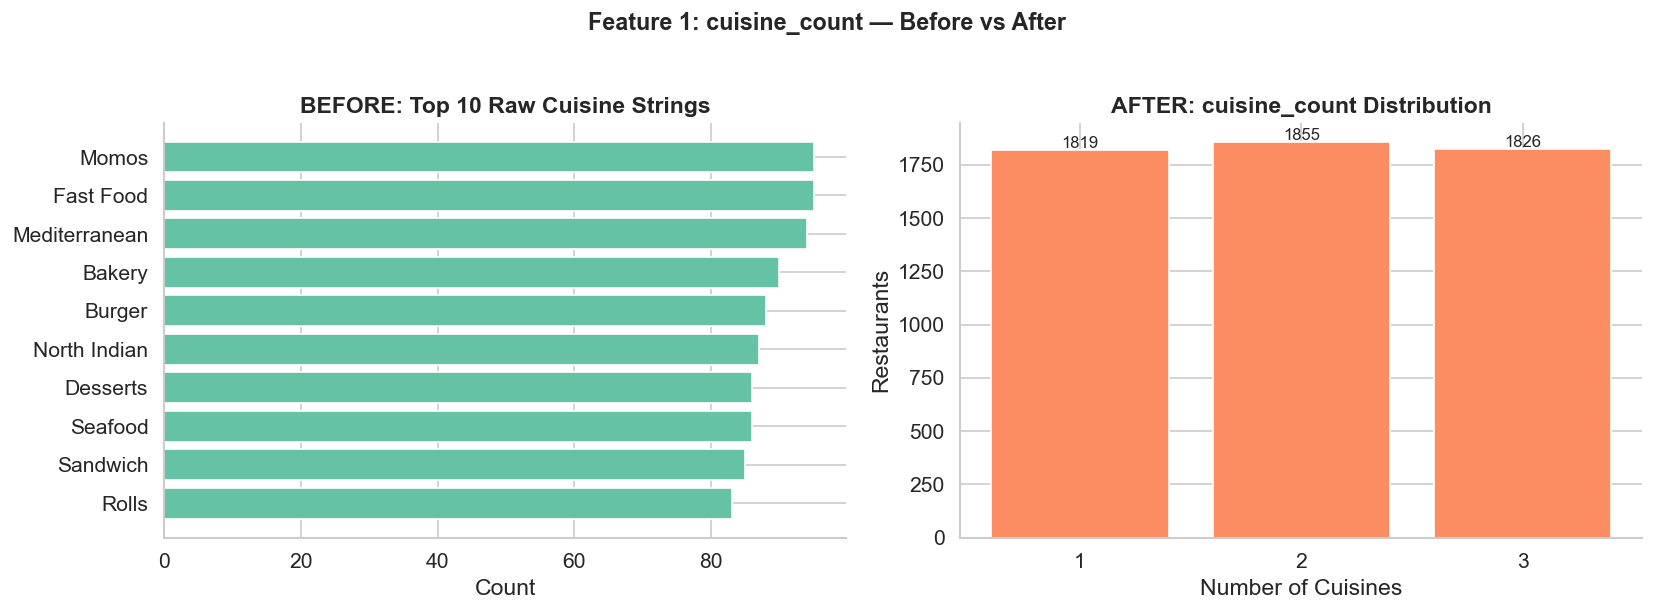

In [2]:
print('=== BEFORE: raw cuisines sample ===')
print(raw['cuisines'].dropna().head(8).to_string())
print()
print('=== AFTER: cuisine_count value counts ===')
print(clean['cuisine_count'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before: top 10 raw cuisine strings
top_raw = raw['cuisines'].dropna().value_counts().head(10)
axes[0].barh(top_raw.index[::-1], top_raw.values[::-1], color=sns.color_palette(PALETTE)[0])
axes[0].set_title('BEFORE: Top 10 Raw Cuisine Strings', fontweight='bold')
axes[0].set_xlabel('Count')

# After: distribution of cuisine_count
vc = clean['cuisine_count'].value_counts().sort_index()
axes[1].bar(vc.index.astype(str), vc.values, color=sns.color_palette(PALETTE)[1], edgecolor='white')
axes[1].set_title('AFTER: cuisine_count Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Cuisines')
axes[1].set_ylabel('Restaurants')
for i, v in enumerate(vc.values):
    axes[1].text(i, v+10, str(v), ha='center', fontsize=10)

for ax in axes: sns.despine(ax=ax)
plt.suptitle('Feature 1: cuisine_count — Before vs After', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('fe_01_cuisine_count.png')
plt.show()


---
## Feature 2 — `is_chain`
**What it is:** Binary flag (1/0) — whether the restaurant name appears in more than one location.

**Before:** Raw `name` column — repeated names spread across locations.

**After:** `is_chain` = 1 if chain, 0 if independent.


=== BEFORE: most repeated restaurant names ===
name
Subway              126
Pizza Hut           120
CafÃ© Coffee Day    108
Haldiram's          105
Barbeque Nation     104
Domino's Pizza      104
McDonald's           99
KFC                  96
Burger King          86
Starbucks            84

=== AFTER: is_chain value counts ===
is_chain
Chain    5500
Name: count, dtype: int64


Saved -> ..\outputs\figures\fe_02_is_chain.png


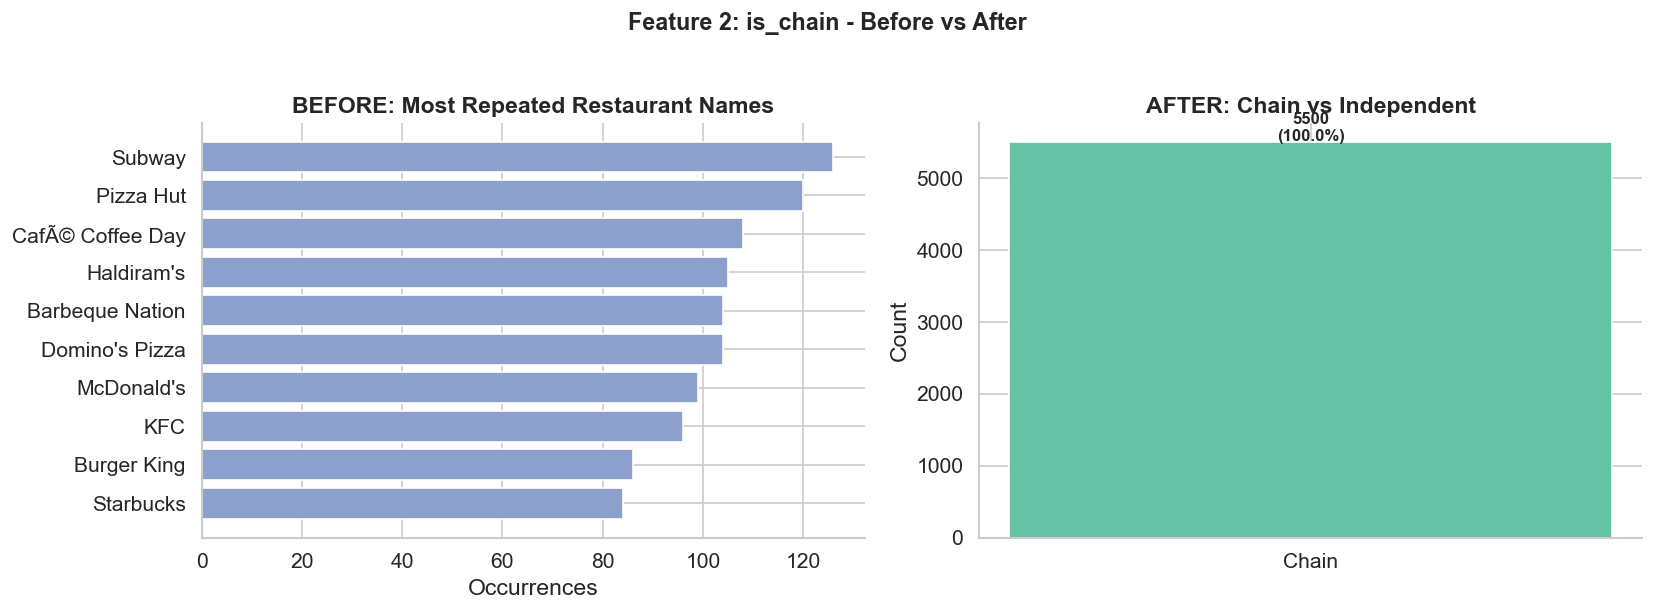

In [3]:
print('=== BEFORE: most repeated restaurant names ===')
print(raw['name'].value_counts().head(10).to_string())
print()
print('=== AFTER: is_chain value counts ===')
print(clean['is_chain'].map({1:'Chain',0:'Independent'}).value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before: top repeated names
top_names = raw['name'].value_counts().head(10)
axes[0].barh(top_names.index[::-1], top_names.values[::-1], color=sns.color_palette(PALETTE)[2])
axes[0].set_title('BEFORE: Most Repeated Restaurant Names', fontweight='bold')
axes[0].set_xlabel('Occurrences')

# After: bar chart of chain vs independent (avoids pie explode length issue)
chain_vc = clean['is_chain'].map({1:'Chain',0:'Independent'}).value_counts()
colors_ci = sns.color_palette(PALETTE, len(chain_vc))
axes[1].bar(chain_vc.index, chain_vc.values, color=colors_ci, edgecolor='white', width=0.4)
for i, (lbl, val) in enumerate(chain_vc.items()):
    pct = val / chain_vc.sum() * 100
    axes[1].text(i, val + 20, f'{val}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('AFTER: Chain vs Independent', fontweight='bold')
axes[1].set_ylabel('Count')

for ax in axes: sns.despine(ax=ax)
plt.suptitle('Feature 2: is_chain - Before vs After', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('fe_02_is_chain.png')
plt.show()


---
## Feature 3 — `price_per_person`
**What it is:** `approx_cost(for two people) / 2` — cost per individual.

**Before:** Raw cost column had commas, stored as string.

**After:** Clean numeric `price_per_person` in rupees.


=== BEFORE: raw cost column sample ===
approx_cost(for two people)
400    321
200    313
900    309
150    306
250    304
450    303
500    284
300    281
700    279
800    268

=== AFTER: price_per_person stats ===
count    5500.0
mean      540.2
std       484.6
min        75.0
25%       175.0
50%       350.0
75%       750.0
max      1750.0
Name: price_per_person, dtype: float64


Saved -> ..\outputs\figures\fe_03_price_per_person.png


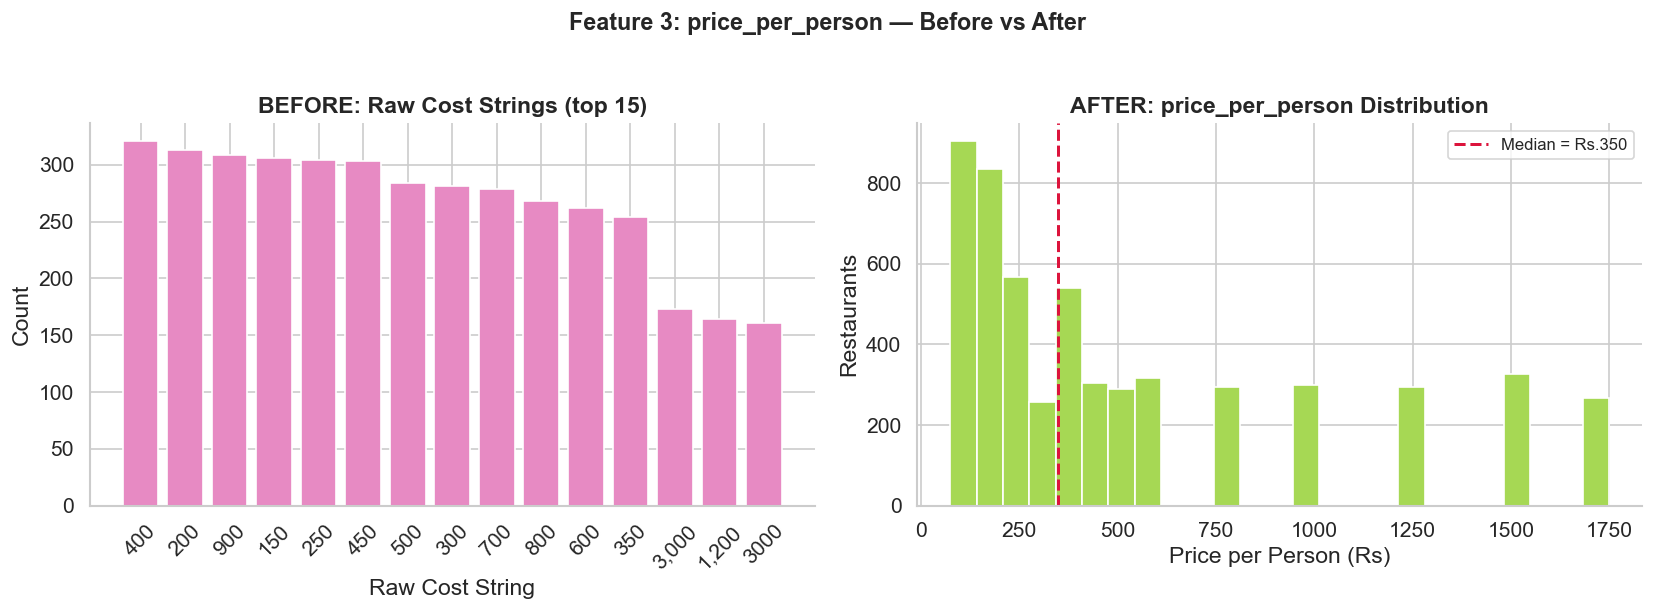

In [4]:
print('=== BEFORE: raw cost column sample ===')
print(raw['approx_cost(for two people)'].value_counts().head(10).to_string())
print()
print('=== AFTER: price_per_person stats ===')
print(clean['price_per_person'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before: raw cost value counts (top 15)
raw_cost = raw['approx_cost(for two people)'].value_counts().head(15)
axes[0].bar(raw_cost.index.astype(str), raw_cost.values,
            color=sns.color_palette(PALETTE)[3], edgecolor='white')
axes[0].set_title('BEFORE: Raw Cost Strings (top 15)', fontweight='bold')
axes[0].set_xlabel('Raw Cost String')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# After: distribution of price_per_person
axes[1].hist(clean['price_per_person'].dropna(), bins=25,
             color=sns.color_palette(PALETTE)[4], edgecolor='white')
med = clean['price_per_person'].median()
axes[1].axvline(med, color='crimson', linestyle='--', linewidth=1.8, label=f'Median = Rs.{med:.0f}')
axes[1].set_title('AFTER: price_per_person Distribution', fontweight='bold')
axes[1].set_xlabel('Price per Person (Rs)')
axes[1].set_ylabel('Restaurants')
axes[1].legend(fontsize=10)

for ax in axes: sns.despine(ax=ax)
plt.suptitle('Feature 3: price_per_person — Before vs After', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('fe_03_price_per_person.png')
plt.show()


---
## Feature 4 — `has_online_order`
**What it is:** Boolean version of the `online_order` Yes/No string column.

**Before:** String `'Yes'` / `'No'` — not directly usable in ML or arithmetic.

**After:** Boolean `True` / `False`.


=== BEFORE: online_order value counts ===
online_order
Yes    3654
No     1956
Name: count, dtype: int64

=== AFTER: has_online_order value counts ===
has_online_order
True     3577
False    1923
Name: count, dtype: int64


Saved -> ..\outputs\figures\fe_04_has_online_order.png


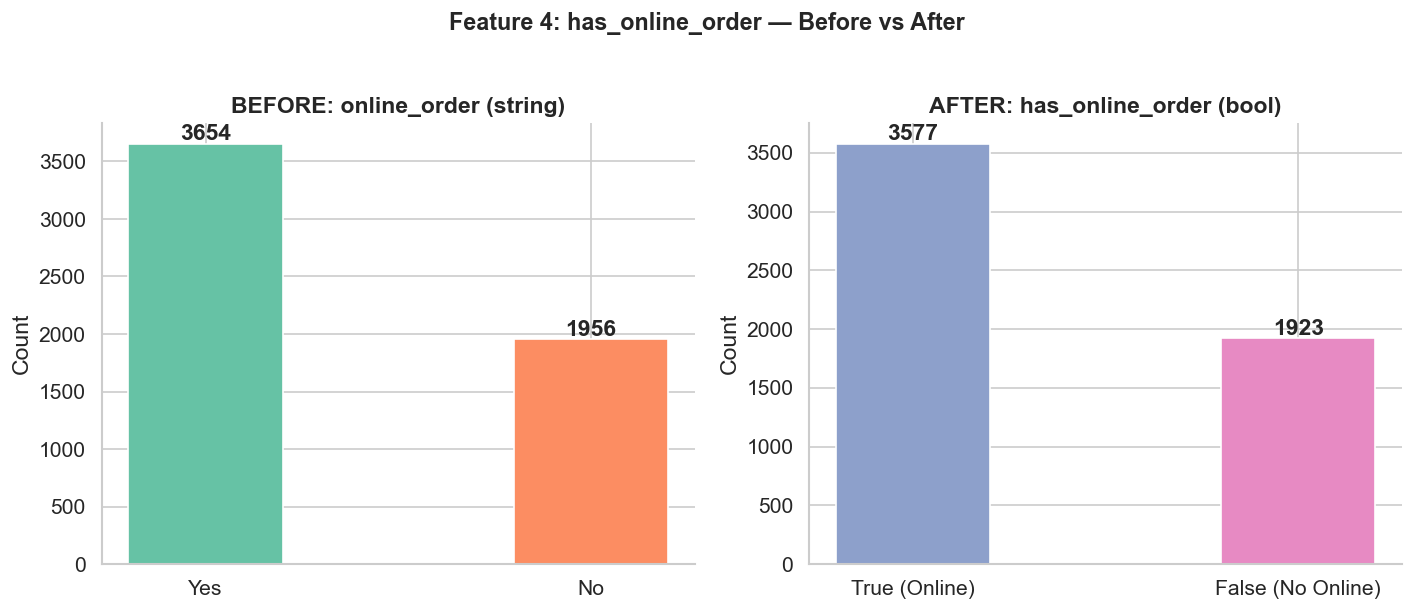

In [5]:
print('=== BEFORE: online_order value counts ===')
print(raw['online_order'].value_counts())
print()
print('=== AFTER: has_online_order value counts ===')
print(clean['has_online_order'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before
bef = raw['online_order'].value_counts()
axes[0].bar(bef.index, bef.values, color=sns.color_palette(PALETTE)[:2], edgecolor='white', width=0.4)
for i, v in enumerate(bef.values):
    axes[0].text(i, v+30, str(v), ha='center', fontweight='bold')
axes[0].set_title('BEFORE: online_order (string)', fontweight='bold')
axes[0].set_ylabel('Count')

# After
aft = clean['has_online_order'].value_counts()
aft.index = aft.index.map({True:'True (Online)', False:'False (No Online)'})
axes[1].bar(aft.index, aft.values, color=sns.color_palette(PALETTE)[2:4], edgecolor='white', width=0.4)
for i, v in enumerate(aft.values):
    axes[1].text(i, v+30, str(v), ha='center', fontweight='bold')
axes[1].set_title('AFTER: has_online_order (bool)', fontweight='bold')
axes[1].set_ylabel('Count')

for ax in axes: sns.despine(ax=ax)
plt.suptitle('Feature 4: has_online_order — Before vs After', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('fe_04_has_online_order.png')
plt.show()


---
## Feature 5 — `rating_bucket`
**What it is:** Ordered categorical bin of the numeric `rate`.

| Bin | Range |
|---|---|
| Poor | 0.0 – 2.5 |
| Average | 2.5 – 3.5 |
| Good | 3.5 – 4.0 |
| Excellent | 4.0 – 5.0 |

**Before:** Continuous float (or messy string like `'4.1/5'`).

**After:** Ordered category — easier to group, visualise, and communicate.


=== BEFORE: raw rate sample ===
rate
NEW      282
4.3/5    198
2.8/5    197
4.8/5    191
4.4/5    188
2.7/5    185
2.1/5    183
2.9/5    181
3.9/5    181
3.5/5    180

=== AFTER: rating_bucket value counts ===
rating_bucket
Poor          910
Average      2134
Good          820
Excellent    1636
Name: count, dtype: int64


Saved -> ..\outputs\figures\fe_05_rating_bucket.png


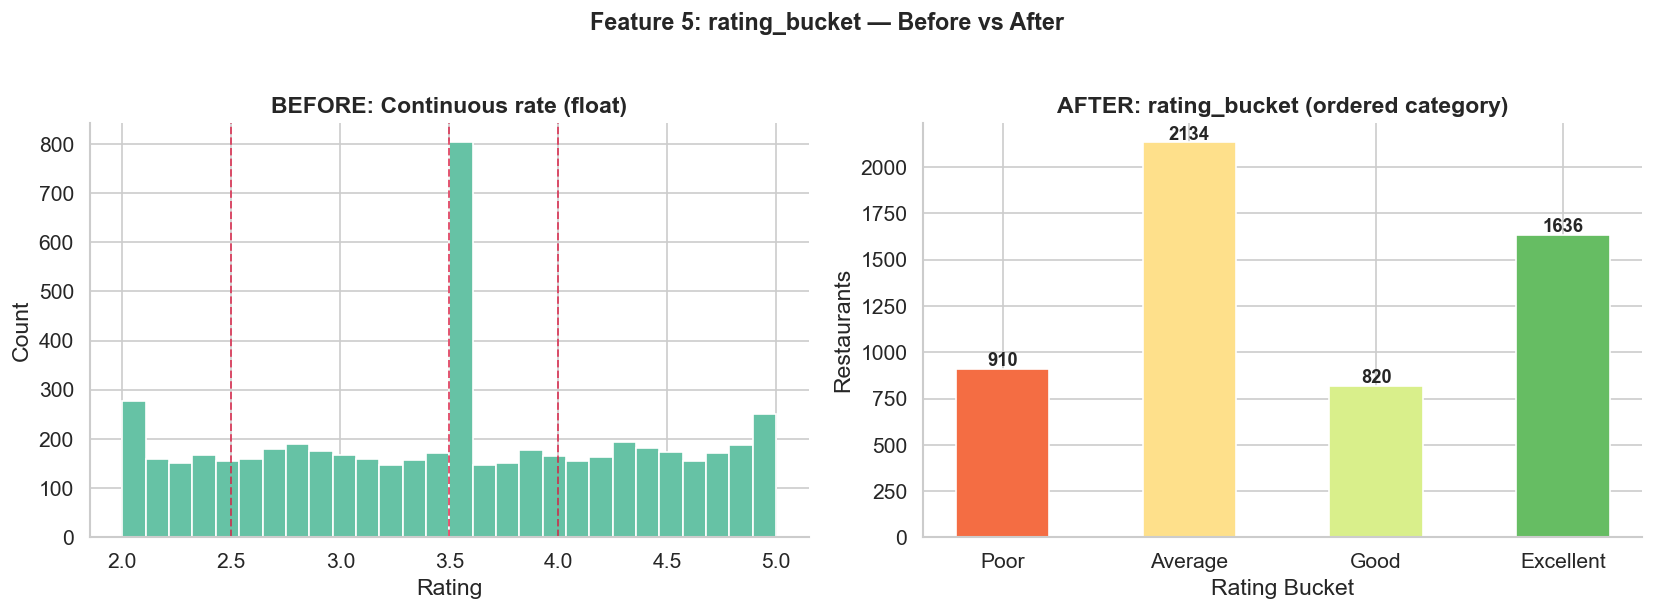

In [6]:
print('=== BEFORE: raw rate sample ===')
print(raw['rate'].value_counts().head(10).to_string())
print()
print('=== AFTER: rating_bucket value counts ===')
print(clean['rating_bucket'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before: histogram of cleaned numeric rate
axes[0].hist(clean['rate'].dropna(), bins=28,
             color=sns.color_palette(PALETTE)[0], edgecolor='white')
axes[0].set_title('BEFORE: Continuous rate (float)', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
for boundary in [2.5, 3.5, 4.0]:
    axes[0].axvline(boundary, color='crimson', linestyle='--', linewidth=1.2, alpha=0.7)

# After: ordered bar chart of buckets
bucket_vc = clean['rating_bucket'].value_counts().sort_index()
colors = sns.color_palette('RdYlGn', 4)
bars = axes[1].bar(bucket_vc.index.astype(str), bucket_vc.values,
                   color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, bucket_vc.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
                 str(val), ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('AFTER: rating_bucket (ordered category)', fontweight='bold')
axes[1].set_xlabel('Rating Bucket')
axes[1].set_ylabel('Restaurants')

for ax in axes: sns.despine(ax=ax)
plt.suptitle('Feature 5: rating_bucket — Before vs After', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('fe_05_rating_bucket.png')
plt.show()


---
## Summary of All Engineered Features
| Feature | Type | Derived From | Purpose |
|---|---|---|---|
| `cuisine_count` | int | `cuisines` | Measures menu diversity |
| `is_chain` | int (0/1) | `name` + `location` | Identifies chain vs independent |
| `price_per_person` | float | `approx_cost` | Comparable unit cost |
| `has_online_order` | bool | `online_order` | ML-ready binary flag |
| `rating_bucket` | ordered category | `rate` | Human-readable rating tier |
